# Q-learning: cliff walking

![](https://www.gymlibrary.dev/_images/cliff_walking.gif)

The agent starts in the bottom-left corner (S) and must reach the goal in the bottom-right corner (G), without stepping into the cliff along the bottom row. Below we'll render this environment ourselves, train a Q-learning agent on it, and then watch the trained agent walk the grid.

In [ ]:
# Install required packages — run this cell once and ignore the output
!pip install -q "gymnasium[toy-text]" pygame

In [ ]:
## Import Libraries
import numpy as np
import gymnasium as gym
import random
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import clear_output, HTML
import seaborn as sns

In [ ]:
## Initialize the CliffWalking environment
env = gym.make('CliffWalking-v1')

# A second copy of the environment with rendering turned on, used purely for
# visualisation. Rendering every step during training would slow the
# 5000-episode loop down a lot, so training and rendering stay separate.
render_env = gym.make('CliffWalking-v1', render_mode='rgb_array')

In [ ]:
## Take a look at the environment before training
# S = start, the checkered squares are the cliff, the goal is bottom-right
render_env.reset(seed=42)
frame = render_env.render()

plt.figure(figsize=(8, 3))
plt.imshow(frame)
plt.axis('off')
plt.title("CliffWalking-v1: get from S to the goal without falling off the cliff")
plt.show()

In [13]:
## Set up Q-learning parameters
action_space_size = env.action_space.n
state_space_size = env.observation_space.n

q_table = np.zeros((state_space_size, action_space_size))

num_episodes = 5000
max_steps_per_episode = 100

learning_rate = 0.1
discount_rate = 0.99

exploration_rate = 1
max_exploration_rate = 1
min_exploration_rate = 0.01
exploration_decay_rate = 0.001

rewards_all_episodes = []

In [ ]:
## Helpers: walk the environment following a policy, and animate the result
def collect_agent_frames(q_table=None, max_steps=max_steps_per_episode, seed=42):
    """Roll out one episode in render_env and collect a frame per step.

    Pass q_table=None to follow a random policy (e.g. before any training),
    or a trained Q-table to follow the greedy policy.
    """
    state, _ = render_env.reset(seed=seed)
    frames = [render_env.render()]

    for _ in range(max_steps):
        if q_table is None:
            action = render_env.action_space.sample()   # no knowledge yet -> random
        else:
            action = np.argmax(q_table[state])          # best known action
        state, _, terminated, truncated, _ = render_env.step(action)
        frames.append(render_env.render())
        if terminated or truncated:
            break

    return frames


def animate_frames(frames, title_prefix='Step'):
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.axis('off')
    im = ax.imshow(frames[0])

    def update(i):
        im.set_data(frames[i])
        ax.set_title(f'{title_prefix} {i}/{len(frames) - 1}')
        return [im]

    anim = animation.FuncAnimation(fig, update, frames=len(frames), interval=400, repeat=False)
    plt.close(fig)
    return HTML(anim.to_jshtml())

In [ ]:
## Before training: the agent knows nothing yet, so it just acts randomly
untrained_frames = collect_agent_frames(q_table=None)
print(f"Random agent ran for {len(untrained_frames) - 1} steps before finishing/timing out")
animate_frames(untrained_frames, title_prefix='Untrained step')

In [15]:
## Q-Learning algorithm
for episode in range(num_episodes):
    state, _ = env.reset()              # ← unpack both values
    done = False
    rewards_current_episode = 0

    for step in range(max_steps_per_episode):

        # ε-greedy action
        if random.random() > exploration_rate:
            action = np.argmax(q_table[state, :])
        else:
            action = env.action_space.sample()

        # NEW: 5-tuple
        new_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated   # treat either signal as “episode finished”

        # Q-update
        q_table[state, action] = (
            (1 - learning_rate) * q_table[state, action] +
            learning_rate * (reward + discount_rate * np.max(q_table[new_state, :]))
        )

        state = new_state
        rewards_current_episode += reward
        if done:
            break

    # ε decay
    exploration_rate = min_exploration_rate + \
        (max_exploration_rate - min_exploration_rate) * np.exp(-exploration_decay_rate * episode)

    rewards_all_episodes.append(rewards_current_episode)


In [16]:
## Calculate and print the average reward per thousand episodes
rewards_per_thousand_episodes = np.split(np.array(rewards_all_episodes), num_episodes/1000)
count = 1000

print("Average reward per thousand episodes")
for r in rewards_per_thousand_episodes:
    print(count, ": ", str(sum(r/1000)))
    count += 1000

Average reward per thousand episodes
1000 :  -563.3330000000002
2000 :  -142.7359999999998
3000 :  -47.52399999999987
4000 :  -27.000000000000544
5000 :  -20.59300000000027


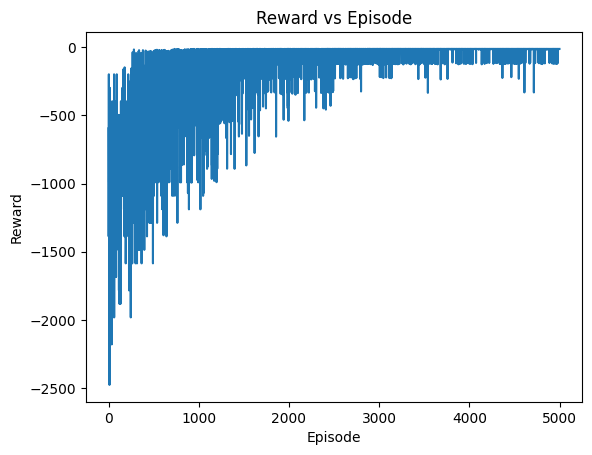

In [17]:
## Plotting the results
plt.plot(range(num_episodes), rewards_all_episodes)
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Reward vs Episode')
plt.show()

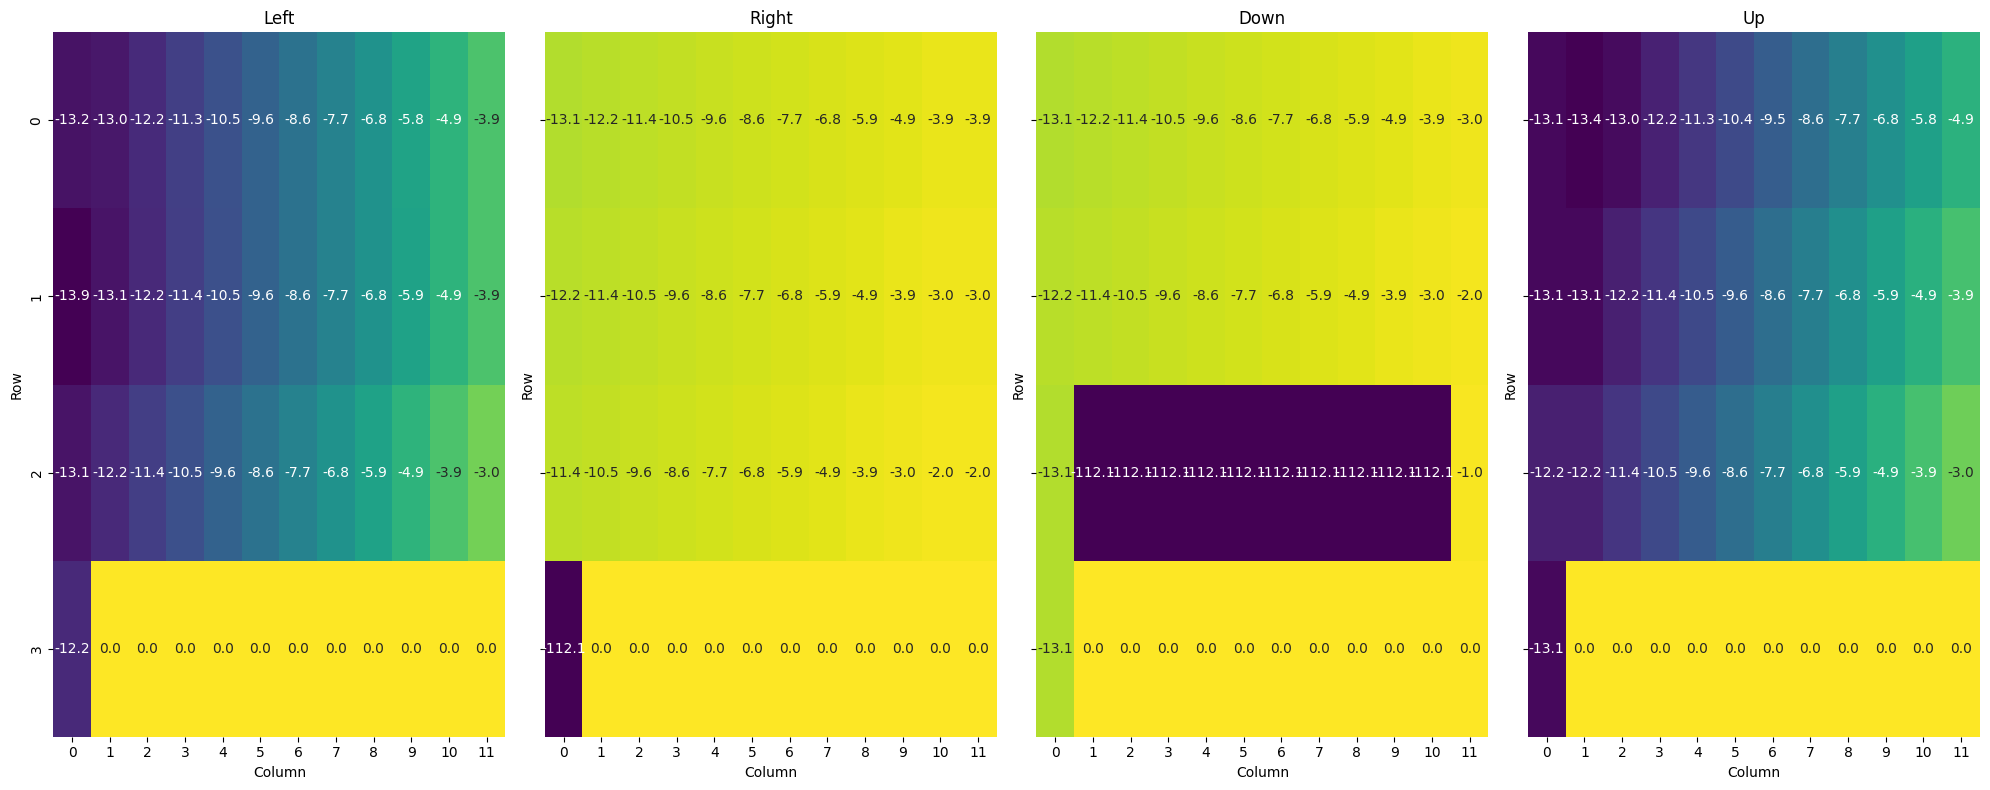

In [18]:
## Visualize the Q-table as heatmap - one for each action up, right, down, left

def plot_q_values_heatmaps(q_table):
    num_states = q_table.shape[0]
    num_actions = q_table.shape[1]

    grid_size = (4, 12)  # CliffWalking-v1 has a 4x12 grid
    fig, axes = plt.subplots(1, num_actions, figsize=(20, 8), sharex=True, sharey=True)

    actions = ['Left', 'Right', 'Down', 'Up']  # Corresponding to each action
    for action in range(num_actions):
        q_values_grid = np.zeros(grid_size)

        for state in range(num_states):
            row, col = divmod(state, grid_size[1])
            q_values_grid[row, col] = q_table[state, action]

        sns.heatmap(q_values_grid, cmap='viridis', annot=True, fmt=".1f", ax=axes[action], cbar=False)
        axes[action].set_title(actions[action])
        axes[action].set_xlabel('Column')
        axes[action].set_ylabel('Row')

    plt.tight_layout()
    plt.show()

plot_q_values_heatmaps(q_table)

In [ ]:
## After training: collect the trained agent's rollout
agent_frames = collect_agent_frames(q_table)
print(f"Trained agent reached a terminal state in {len(agent_frames) - 1} steps")

In [ ]:
## Animate the trained agent walking across the cliff
animate_frames(agent_frames, title_prefix='Step')